# **Logistic Regression**

<div align="center">
    <img src="img/log-reg-0.png" width="30%">
</div>

### **Práctica de Regresión Lógistica: Cancer de mama**

**Base de datos**: [Click](https://drive.google.com/file/d/1YccFuyedpJ7-rek4iR3MSviB0jv80uqZ/view?usp=sharing)

El conjunto de datos contiene casos de un estudio realizado entre 1958 y 1970 en el Hospital Billings de la Universidad de Chicago sobre la supervivencia de pacientes que se habían sometido a cirugía por cáncer de mama.

La base de datos está formada por 306 objetos, cada objeto tiene 3 características (Edad del paciente al momento de la operación, Años de operación y Número de ganglios axilares positivos detectados) y un predictor (variable a predecir estado de supervivencia, 1 si el paciente vivió, 2 si el paciente murío)

*Se pide predecir, en base a las características de un paciente,  si un paciente sobrevivirá o no*

In [19]:
%matplotlib widget

import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import random
import math

EPS = math.e

### **Dataset**

In [2]:
df = pd.read_csv("dataset.data", header=None)
df.columns = ["age", "years-op", "ganglia", "predictor"]
df["w0"] = 1
df.head(5)

,age,years-op,ganglia,predictor,w0
0,30,64,1,1,1
1,30,62,3,1,1
2,30,65,0,1,1
3,31,59,2,1,1
4,31,65,4,1,1


In [3]:
x = df[["w0", "age", "years-op", "ganglia"]].to_numpy().astype(float)
y = np.array(df["predictor"]).astype(float)

display(x)
# display(y)
display(x.shape, y.shape)

array([[ 1., 30., 64.,  1.],
       [ 1., 30., 62.,  3.],
       [ 1., 30., 65.,  0.],
       ...,
       [ 1., 77., 65.,  3.],
       [ 1., 78., 65.,  1.],
       [ 1., 83., 58.,  2.]])

(306, 4)

(306,)

In [4]:
# NORMALIZE DATA
r, c = x.shape
for j in range(1, c):
    # Get max and min of current column
    max_x = np.amax(x[:,j])         
    min_x = np.amin(x[:,j])
    
    x[:,j] = np.array([(e - min_x)/(max_x - min_x) for e in x[:,j]])

max_y = np.amax(y)
min_y = np.amin(y)
y = np.array([( e - min_y)/(max_y - min_y) for e in y])

display(x.shape, y.shape)
display(x, y)

(306, 4)

(306,)

array([[1.        , 0.        , 0.54545455, 0.01923077],
       [1.        , 0.        , 0.36363636, 0.05769231],
       [1.        , 0.        , 0.63636364, 0.        ],
       ...,
       [1.        , 0.88679245, 0.63636364, 0.05769231],
       [1.        , 0.90566038, 0.63636364, 0.01923077],
       [1.        , 1.        , 0.        , 0.03846154]])

array([0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 0., 0.,
       0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 1., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 0.

In [5]:
# 70% for train and 30% test
m, = y.shape
idx = np.array(np.arange(m))
include_idx = set(np.random.choice(idx, size = int(0.7*m), replace=False))
mask = np.array([(i in include_idx) for i in range(m)])

trainX = x[mask]
testX = x[~mask]

trainY = y[mask]
testY = y[~mask]

display(trainX.shape, testX.shape)
display(trainY.shape, testY.shape)

(214, 4)

(92, 4)

(214,)

(92,)

### **Plotting data**

Text(0.5, 0, 'ganglia')

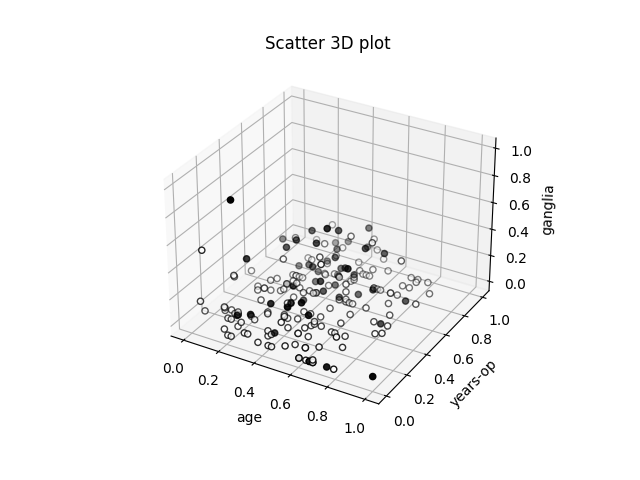

In [6]:
# 3D PLOT
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(trainX[:,1], trainX[:,2], trainX[:,3], c=trainY, cmap="binary", edgecolors='black')
ax.set_title('Scatter 3D plot')
ax.set_xlabel('age')
ax.set_ylabel('years-op')
ax.set_zlabel('ganglia')

Text(0.5, 0, 'ganglia')

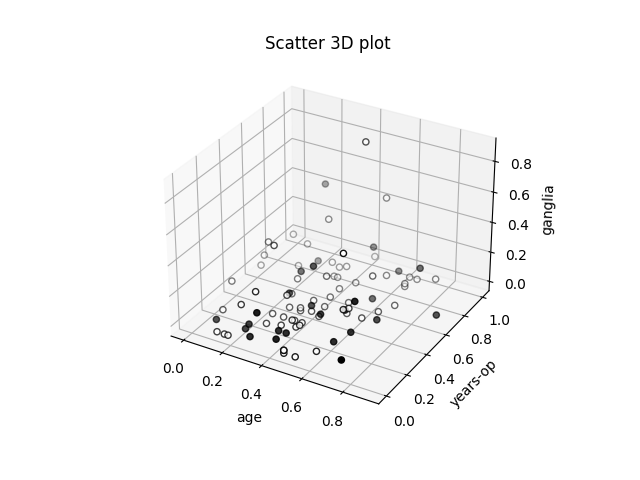

In [7]:
# 3D PLOT
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(testX[:,1], testX[:,2], testX[:,3], c=testY, cmap="binary", edgecolors='black')
ax.set_title('Scatter 3D plot')
ax.set_xlabel('age')
ax.set_ylabel('years-op')
ax.set_zlabel('ganglia')

#### **Hypothesis**

For $n$ features:

- Ecuación de la recta o hiperplano

$$h(x^{(i)}) = w_0*1 + w_1 * x^{(i)}_1 + w_2 * x^{(i)}_2 + w_n * x^{(i)}_n$$
$$h(x^{(i)}) = <x^{(i)}, w> = x^{(i)} . w^T$$ 

- Ecuación de la función sigmoidea (clasificador binario)

$$s(x^{(i)}) = \frac{1}{1 - \epsilon^{h(x^{(i))}}} = \frac{1}{1 - \epsilon^{x^{(i)} . w^T}}$$

In [8]:
def h(x, w):
    return np.sum(np.multiply(x, w))

def s(x, w):
    return 1/(1+EPS**(-1 * h(x,w)))

### **Error**

- **Loss Function** (Cross-Entropy)

\begin{equation}
L = -\frac{1}{n}\sum_{i=0}^n(y_ilog(s(x_i)) + (1-y_i)log(1-s(x_i)))  
\end{equation} \\


For $m$ training examples:

$$L(x) = \text{Error} = \frac{-1}{m} \sum_{i=0}^m ( y^{(i)} . \log(s(x^{(i)})) + (1 - y^{(i)}) . \log(1 - s(x^{(i)})))$$

Where:

$y^{(i)} . \log(s(x^{(i)}))$

$(1 - y^{(i)}) . \log(1 - s(x^{(i)}))$


In [9]:
def l(x, w, y):
    m, = y.shape
    on = np.ones(m)
    
    logSX = np.log(np.array([s(te, w) for te in x]));
    cLogSX = np.log(np.array([(1 - s(te, w)) for te in x]))

    # display(logSX)
    # display(cLogSX)

    return np.sum(
            np.multiply(y, logSX) + np.multiply(on - y, cLogSX)
        )* (-1/m)

## **Gradient Descent**

$$
\frac{\partial{L}}{\partial{w_0}} = \frac{1}{m}\sum_{i=0}^m(y_i - h(x^i))(-1) \\
\frac{\partial{L}}{\partial{w_{j\neq 0}}} = \frac{1}{m}\sum_{i=0}^m(y_i - h(x^i))(-x^{i}_{j})
$$

In [10]:
def derivatives(x, y, w):
    n, c = x.shape
    return np.array([
                np.sum(
                        [
                                1/n * (y[i] - s(x[i,:], w)) * (-1 if j == 0 else -x[i,j]) for i in range(n)
                        ]
                ) for j in range(c)
            ])
        

## **Change parameter**

$$w_i = w_i - \alpha * \frac{\partial{\text{ Loss}}}{\partial{w_i}}$$


In [11]:
def update(w, alfa, deriv):
    return w - alfa*deriv

In [12]:
def test(x_test, w, y_test):
    return l(x_test, w, y_test)

- **Training** 

Seleccione $70\%$ de los datos del dataset para entrenamiento y el resto para testing. Recuerde, los datos deben ser seleccionados de manera aleatoría.


In [13]:
arrL = []
arrT = []

def train(x, y, alfa, epochs):
    r, c = x.shape
    w = np.array([np.random.rand() for i in range(c)])     # k+1 parametros w0 + w1x1 + ... wkxk
    # print(w)
    for _ in range(epochs):
        L = l(x, w, y)
        arrL.append(L)
        der = derivatives(x, y, w)
        w = update(w, alfa, der)
        
        arrT.append(test(testX, w, testY))
        
        if _ % 50 == 0:
            print(f"L: {L} ", end="")
        if _ % 100 == 0:
            print()
    return w
        

In [14]:
alfa = 0.5
epochs = 2000

In [15]:
arrL = []
arrT = []

res = train(trainX, trainY, alfa, epochs)

L: 0.9053013376280359 
L: 0.5491708749430527 L: 0.5394128204334523 
L: 0.5316902853311488 L: 0.5255039311746594 
L: 0.5204999508680813 L: 0.5164188317042167 
L: 0.5130661269746873 L: 0.5102939588616208 
L: 0.5079885050425162 L: 0.5060612187531337 
L: 0.5044425413256052 L: 0.5030773369029596 
L: 0.5019215389365889 L: 0.5009396598143767 
L: 0.5001029218280921 L: 0.4993878400920464 
L: 0.49877513764494996 L: 0.49824890723574927 
L: 0.4977959581437306 L: 0.49740530312447373 
L: 0.49706775243612766 L: 0.4967755903901931 
L: 0.4965223160079507 L: 0.4963024338439822 
L: 0.4961112843405027 L: 0.4959449055325185 
L: 0.4957999197666955 L: 0.4956734404907658 
L: 0.49556299523275127 L: 0.49546646170492326 
L: 0.4953820145978151 L: 0.4953080811199424 
L: 0.49524330372257336 L: 0.49518650875083176 
L: 0.4951366800013073 L: 0.49509293635631185 
L: 0.4950545128167222 L: 0.49502074437720606 
L: 0.4949910522858813 

- **Testing**

Utilize el $30\%$ de los datos restantes para el proceso de testing. 

In [16]:
def testing(x_test, y_test, w):
  n = len(y_test)
  y_pred = []
  for i in range(n):
    y_pred.append(round(s(x_test[i, :], w)))
  
  aciertos = sum(y_pred == y_test)
  print("Número de datos de test: ", n)
  print("Número de datos correctos: ", aciertos)
  print(f"Porcentaje de aciertos: {100*aciertos/n} %")
  print(f"Porcentaje de fallos: {100*(n - aciertos)/n} %")

## **Desarrolle las siguientes actividades**

- Implemente funciones para graficar la función de pérdida. 
- Implemente la función para mostrar las funciones de error de training vs testing 
- ¿Qué porcentaje de aciertos tiene el método?
- ¿Qué porcentaje de fallas tiene el método?

In [17]:
testing(testX, testY, res)

Número de datos de test:  92
Número de datos correctos:  62
Porcentaje de aciertos: 67.3913043478261 %
Porcentaje de fallos: 32.608695652173914 %


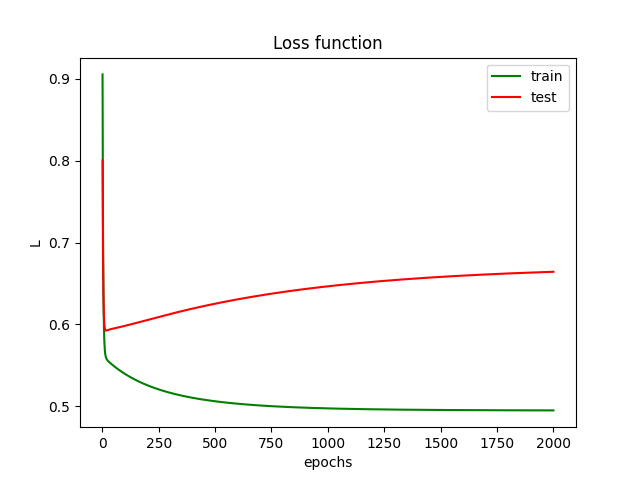

In [18]:
# 2D PLOT
fig = plt.figure()
plt.title("Loss function")
plt.ylabel("L")
plt.xlabel("epochs")
plt.plot(np.arange(1,len(arrL)+1), arrL, color="green", label="train")
plt.plot(np.arange(1,len(arrT)+1), arrT, color="red", label="test")
plt.legend()

### **References**

- [Map function over np.array](https://stackoverflow.com/questions/35215161/most-efficient-way-to-map-function-over-numpy-array)
- [Natural Logarithmic](https://datagy.io/python-natural-log/)
- [Derivative of Cost Function](https://medium.com/analytics-vidhya/derivative-of-log-loss-function-for-logistic-regression-9b832f025c2d)
- [Why Does the Cost Function of Logistic Regression Have a Logarithmic Expression?](https://www.baeldung.com/cs/cost-function-logistic-regression-logarithmic-expr)
- [Loss Function](https://towardsdatascience.com/optimization-loss-function-under-the-hood-part-ii-d20a239cde11)
- [Loss Function Derivative 2](https://math.stackexchange.com/questions/477207/derivative-of-cost-function-for-logistic-regression)
- [Building a Logistic Regression in Python](https://towardsdatascience.com/building-a-logistic-regression-in-python-step-by-step-becd4d56c9c8)